In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ["MPLCONFIGDIR"] = f"/tmp/{os.environ['USER']}_matplotlib_cache"

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [3]:
import sys
import warnings

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import healpy as hp
from cogwheel import gw_utils, utils

sys.path.insert(0, '/home/abbye.williams/GWPE/code')
import helpers

warnings.simplefilter("ignore", RuntimeWarning)

### expected scaling $\mathcal L^\mathrm{max}_\mathrm{II} - \mathcal L^\mathrm{max}_\mathrm{I}\approx\ln\mathcal B^\mathrm{II}_\mathrm{I}$

$$
\ln\mathcal L^\mathrm{max}_\mathrm{II} - \ln\mathcal L^\mathrm{max}_\mathrm{I} = \frac{\rho^2}{2}\left(1 - \frac{\left(\mu\varepsilon\sum_d \vert\vec F^{(d)}\vert^2\langle H^{(d)}|H^{(d)}\rangle\right)^2}{\sum_d\left[\left(\varepsilon F_+^{(d)}\right)^2 + \left(\mu F_\times^{(d)}\right)^2\right]\langle H^{(d)}|H^{(d)}\rangle\sum_d\left[\left(\varepsilon F_\times^{(d)}\right)^2 + \left(\mu F_+^{(d)}\right)^2\right]\langle H^{(d)}|H^{(d)}\rangle}\right)
$$
with $\mu\equiv\cos\iota$, $\varepsilon\equiv(1+\mu^2)/2$, and $H^{(d)}\equiv S_m^{(d)} h_m^{(d)}$

#### antenna response functions

In [4]:
nside = 32
ipix = np.arange(hp.nside2npix(nside))
theta, phi = hp.pixelfunc.pix2ang(nside, ipix)  # theta \in [0, π] and phi \in [0, 2π]
# convert (theta, phi) -> (RA, Dec)
ra, dec = theta, phi - np.pi / 2
detector_names = ('H', 'L', 'V')
# pick a time and polarization angle
tgps = 0.
psi = 0.
fplus, fcross = np.array([
    gw_utils.fplus_fcross(detector_names, ra_, dec_, psi, tgps).T for (ra_, dec_) in zip(ra, dec)
]).T

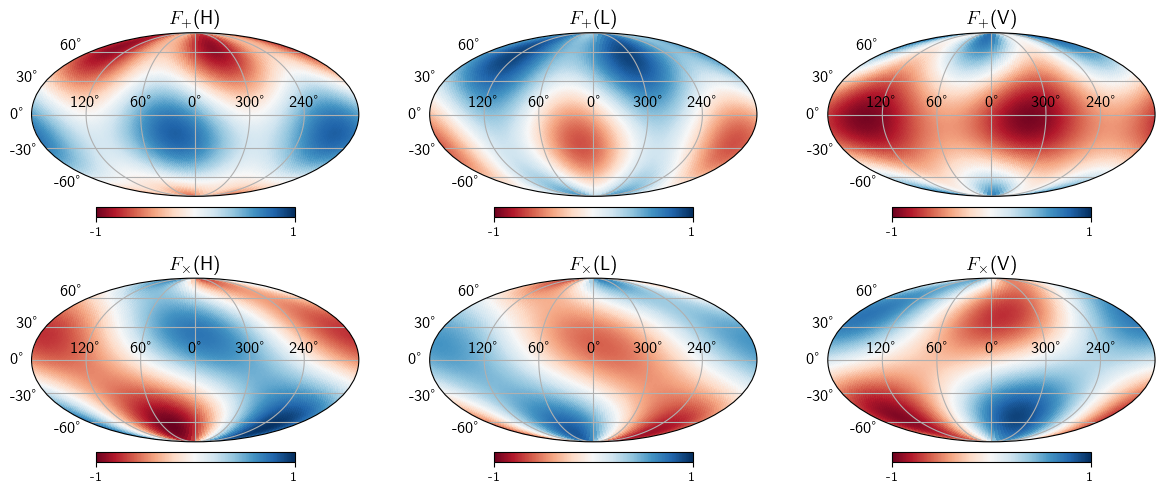

In [7]:
fig = plt.figure(figsize=(12,5))
for i, (fstr, farr) in enumerate(zip([r'$F_+$', r'$F_\times$'], [fplus, fcross])):
    for j, (det_name, f_det) in enumerate(zip(detector_names, farr)):
        hp.projview(f_det, sub=(2, 3, len(farr) * i + j+1 ), cmap='RdBu', coord=['C'], title=fstr + f'({det_name})',
                    min=-1., max=1., graticule=True, graticule_labels=True)

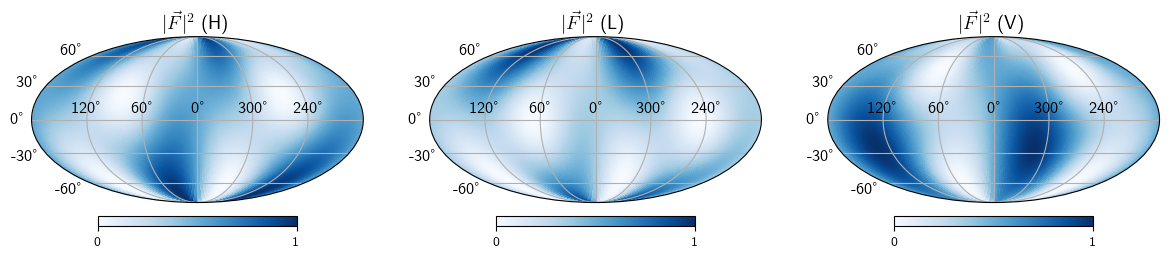

In [8]:
# what about the norm squared?
fsq = fplus**2 + fcross**2
fig = plt.figure(figsize=(12,3))
for i, (det_name, fsq_det) in enumerate(zip(detector_names, fsq)):
    hp.projview(fsq_det, fig=fig, cmap='Blues', coord=['C'], title=r'$|\vec F|^2$'f' ({det_name})', sub=(1, 3, i+1),
                min=0., max=1., graticule=True, graticule_labels=True)

#### construct $H = S_m h_m$

In [9]:
# load a sampler
approximant = 'IMRPhenomXPHM'
resdir = f'/home/abbye.williams/GWPE/data/injections/Halton/{approximant}/IntrinsicLVCPrior'
seed = 12
idx = 0
eventname = f'GW{seed}_{idx}'
eventdir = os.path.join(resdir, eventname)
sampler = utils.read_json(os.path.join(eventdir, 'run_0', 'Sampler.json'))

In [10]:
like = sampler.posterior.likelihood
# which harmonic modes are present in the signal?
harmonic_modes = like.waveform_generator.harmonic_modes
m_arr = like.waveform_generator.m_arr
print(f"harmonic modes: ", harmonic_modes)
# get the injected parameters
par_dic = sampler.posterior.likelihood.event_data.injection['par_dic']
# waveform (frequency domain) in each detector
h = sampler.posterior.likelihood._get_h_f(par_dic, by_m=True)

harmonic modes:  [(2, 2), (2, 1), (3, 3), (3, 2), (4, 4)]


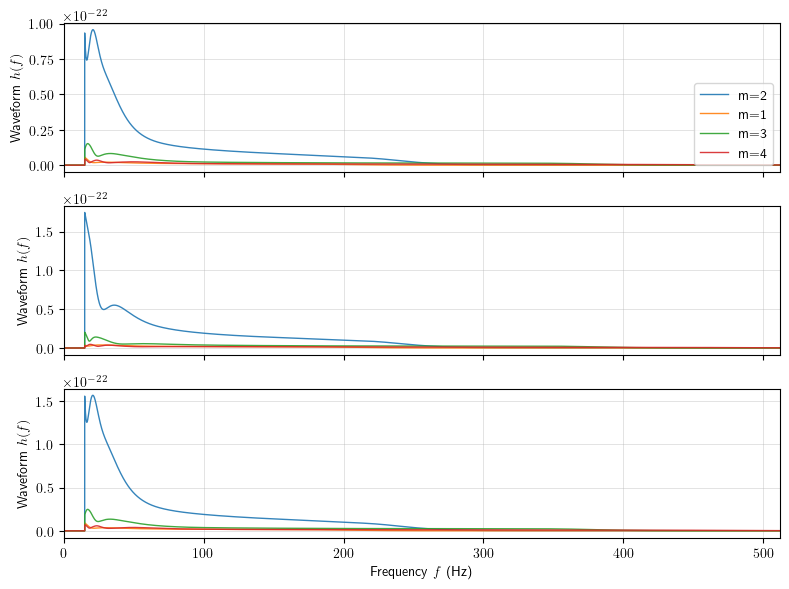

In [11]:
# plot these
fig, axs = plt.subplots(3, 1, figsize=(8,6), tight_layout=True)
for i, ax in enumerate(axs):
    for j, m in enumerate(m_arr):
        ax.plot(like.event_data.frequencies, np.abs(h[j,i]), alpha=0.9, lw=1, label=f'm={m}')
    ax.grid(alpha=0.5, lw=0.5)
    ax.set_ylabel(r'Waveform $h(f)$')
    ax.set_xlim(0., like.event_data.frequencies.max())
    if ax is not axs[-1]:
        ax.set_xticklabels([])
axs[-1].set_xlabel(r'Frequency $f$ (Hz)')
axs[0].legend(loc=4)

### expected mismatch: randomly sampled $(\mathrm{RA},\mathrm{Dec},\psi)$

Text(0.5, 1.0, '500 GW events (isotropic)')

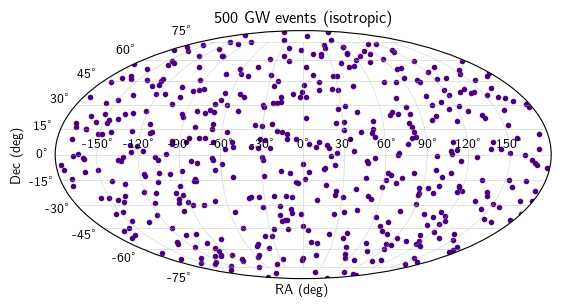

In [4]:
# to sample from an istropic sky distribution, we want a uniform distribution in RA, and a uniform distribution in sin(Dec)
rng = np.random.default_rng()
n = 500
ra = rng.uniform(0., 2 * np.pi, n)
sindec = rng.uniform(-1., 1., n)
dec = np.arcsin(sindec)
# plot
fig = plt.figure()
plt.subplot(111, projection='mollweide')
plt.scatter(ra - np.pi, dec, marker='.', c='indigo')
plt.grid(alpha=0.5, lw=0.5)
plt.xlabel('RA (deg)')
plt.ylabel('Dec (deg)')
plt.title(f'{n} GW events (isotropic)')

In [5]:
# okay but we could also try this uniformly across the sky using healpix
nside = 16
ipix = np.arange(hp.nside2npix(nside))
theta, phi = hp.pixelfunc.pix2ang(nside, ipix)  # theta \in [0, π] and phi \in [0, 2π]
# convert (theta, phi) -> (RA, Dec)
ra, dec = theta, phi - np.pi / 2

In [6]:
# get HH from one of the injections
idx = 0
samples_dir = f'/home/abbye.williams/GWPE/data/injections/Halton/IMRPhenomXPHM/IntrinsicLVCPrior/GW12_{idx}/run_0'
sampler = utils.read_json(os.path.join(samples_dir, 'Sampler.json'))
HH = helpers.compute_HH(sampler.posterior.likelihood)
# get the polarization from the injection
# psi = sampler.posterior.likelihood.event_data.injection['par_dic']['psi']

In [30]:
iotas = np.arange(0., np.pi / 2 + 0.001, 0.001 * np.pi)
mus = np.cos(iotas)

detector_names = ('H', 'L', 'V')
tgps = 0.
psi = 0. # ! note we've determined that though we need psi to compute the antenna response functions,
            # the final mismatch is actually independent of psi !

# compute the expected mismatch as a function of inclination for each of these locations

fplus, fcross = np.array([
    gw_utils.fplus_fcross(detector_names, ra_, dec_, psi, tgps).T for (ra_, dec_) in zip(ra, dec)
]).T
mismatches_arr = np.empty((len(ra), len(mus)))
for i, (fplus_, fcross_) in enumerate(zip(fplus.T, fcross.T)):
    mismatches_arr[i] = np.array([
        helpers.expected_mismatch_with_HH(fplus_, fcross_, mu, HH) for mu in mus
    ])
mismatch_dic = {
    'avg' : np.mean(mismatches_arr, axis=0),
    'min' : np.min(mismatches_arr, axis=0),
    'max' : np.max(mismatches_arr, axis=0)
}

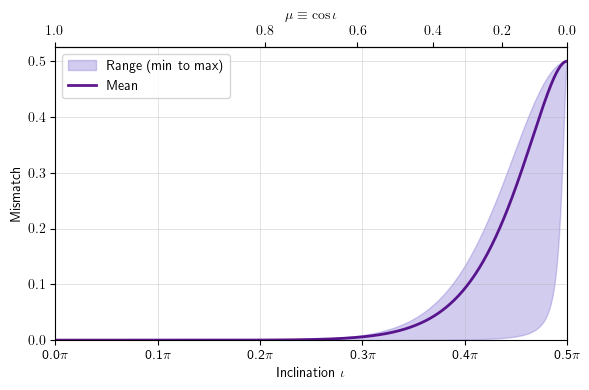

In [33]:
fig, ax = plt.subplots(figsize=(6,4), tight_layout=True)
xticks = np.arange(0., 0.51, 0.1) * np.pi
xticklabels = [f'{x / np.pi:.1f}'r'$\pi$' for x in xticks]

ax.fill_between(iotas, mismatch_dic['min'], mismatch_dic['max'],
                color='slateblue', alpha=0.3, label='Range (min to max)')
ax.plot(iotas, mismatch_dic['avg'], c='indigo', lw=2, alpha=0.9, label='Mean')

ax.grid(alpha=0.5, lw=0.5)
ax.set_xlim(0., np.pi/2)
ax.set_ylim(0., None)
ax.set_xticks(xticks, labels=xticklabels)
ax.set_xlabel(r'Inclination $\iota$')
secax = ax.secondary_xaxis('top', functions=(lambda x: np.cos(x), lambda x: np.arccos(x)))
secax.set_xlabel(r'$\mu\equiv\cos\iota$')
ax.set_ylabel(r'Mismatch')# $\ln\mathcal B / \rho^2$')
ax.legend()

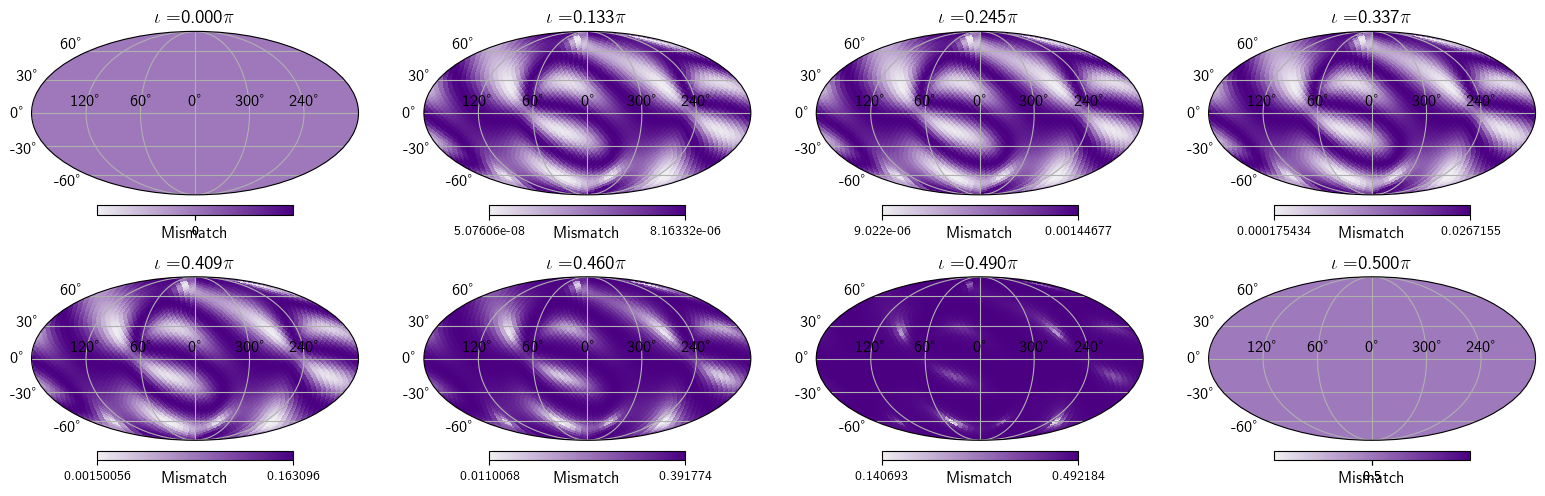

In [49]:
# let's get a sample of inclinations from a power law
N = 8
power = 2
t = np.linspace(0, 1, N)    # evenly spaced
n = len(iotas) - 1
iiotas = n - (n * (1 - t)**power).astype(int)
# plot
fig = plt.figure(figsize=(16,5))
for i, iiota in enumerate(iiotas):
    title = r'$\iota = $'f'{iotas[iiota] / np.pi:.3f}'r'$\pi$'
    cmap = sns.light_palette('indigo', as_cmap=True)
    hp.projview(mismatches_arr[:,iiota], coord=['C'],
                cmap=cmap, sub=(2,4,i+1), fig=fig,
                graticule=True, graticule_labels=True, unit='Mismatch', title=title)

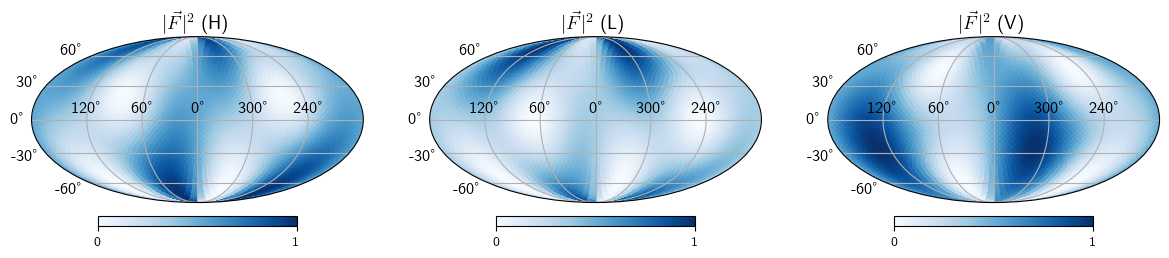

In [42]:
fsq = fplus**2 + fcross**2
fig = plt.figure(figsize=(12,3))
for i, (det_name, farr) in enumerate(zip(detector_names, fsq)):
    hp.projview(farr, cmap='Blues', fig=fig, sub=(1, 3, i+1), title=r'$|\vec F|^2$'f' ({det_name})', graticule=True, graticule_labels=True, min=0., max=1.)

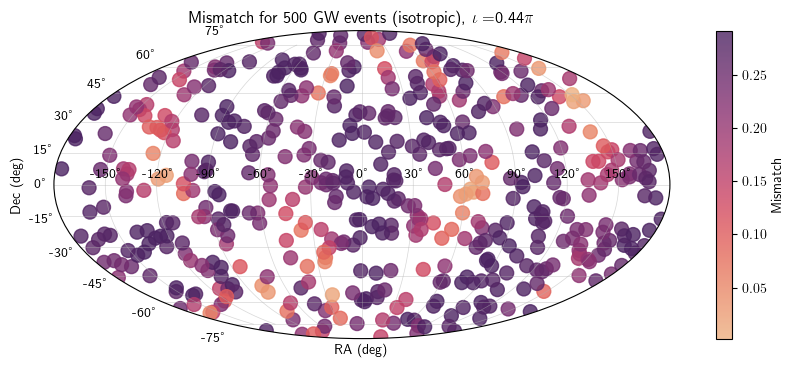

In [48]:
# what do these look like on the sky, for a fixed iota ?
iiota = -20
fig = plt.figure(figsize=(12,4))
plt.subplot(111, projection='mollweide')
im = plt.scatter(ra - np.pi, dec, marker='o', s=100, alpha=0.8, c=mismatches[:,iiota],
                 cmap=sns.color_palette('flare', as_cmap=True))
plt.grid(alpha=0.5, lw=0.5)
plt.xlabel('RA (deg)')
plt.ylabel('Dec (deg)')
plt.title(f'Mismatch for {n} GW events (isotropic), 'r'$\iota = $'f'{iotas[iiota] / np.pi:.2f}'r'$\pi$')
plt.colorbar(im, label='Mismatch', shrink=1.)